In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

print(project_root)

c:\Users\mert4325\OneDrive - Nexus365\DPhil\Python\cat-breeding-simulation


## 1. Squeezed cat state

The even cat state is

$$
|\mathrm{cat}_+\rangle =
\mathcal{N}_+
\left(
|\alpha\rangle + |-\alpha\rangle
\right).
$$

The squeezed cat is obtained by applying the single-mode
squeezing operator,

$$
|\mathrm{SC}\rangle = S(r)|\mathrm{cat}_+\rangle.
$$

In [2]:
from src.states import make_squeezed_cat
N=40
alpha=1.5
r=0.5
squeezed_cat = make_squeezed_cat(N, alpha, r
)

## 2. Two-mode input and beamsplitter

The two input modes are prepared independently in identical
squeezed cat states,

$$
|\Psi_{\mathrm{in}}\rangle
=
|\mathrm{SC}\rangle_A
\otimes
|\mathrm{SC}\rangle_B.
$$

The two modes interfere at a 50:50 beamsplitter. We use the
unitary

$$
U_{\mathrm{BS}}(\theta)
=
\exp\left[
\theta
\left(
a_A^\dagger a_B-a_Aa_B^\dagger
\right)
\right],
$$

with

$$
\theta=\frac{\pi}{4}.
$$

The output state is therefore

$$
|\Psi_{\mathrm{out}}\rangle
=
U_{\mathrm{BS}}|\Psi_{\mathrm{in}}\rangle.
$$

In [3]:
import qutip as qt
psi_in = qt.tensor(squeezed_cat, squeezed_cat)

from src.beamsplitter import apply_beamsplitter

psi_out = apply_beamsplitter(psi_in, N)

#test - remove later
print("Input norm:", psi_in.norm())
print("Output norm:", psi_out.norm())

Input norm: 1.0
Output norm: 0.9999999999999994


In [5]:
from src.homodyne import momentum_fock_wavefunctions
import numpy as np 

N_test = 5
p_test = np.linspace(-5, 5, 1000)

phi_test = momentum_fock_wavefunctions(
    p_test,
    N_test
)

print(phi_test.shape)

(1000, 5)


In [6]:
from src.homodyne import conditional_states

conditional_unnorm = conditional_states(
    psi_out,
    p_test
)

print(conditional_unnorm.shape)

(1000, 40)


In [7]:
pdf_test = np.sum(
    np.abs(conditional_unnorm)**2,
    axis=1
)

print(pdf_test.shape)

print(
    np.trapezoid(
        pdf_test,
        p_test
    )
)

(1000,)
0.9999792916458758


In [8]:
from src.homodyne import homodyne_pdf

pdf_test, conditional_unnorm = homodyne_pdf(
    psi_out,
    p_test
)

print(
    "PDF integral:",
    np.trapezoid(pdf_test, p_test)
)

PDF integral: 1.0


## Homodyne probability distribution

For each possible momentum outcome \(p\), the unnormalised conditional
state of the unmeasured mode is

$$
|\tilde{\psi}_B(p)\rangle
=
{}_A\langle p|\Psi_{\mathrm{out}}\rangle.
$$

The probability density for observing the homodyne outcome \(p\) is
given by Born's rule,

$$
P(p)
=
\langle\tilde{\psi}_B(p)
|
\tilde{\psi}_B(p)\rangle.
$$

The probability density is normalised such that

$$
\int P(p)\,dp = 1.
$$

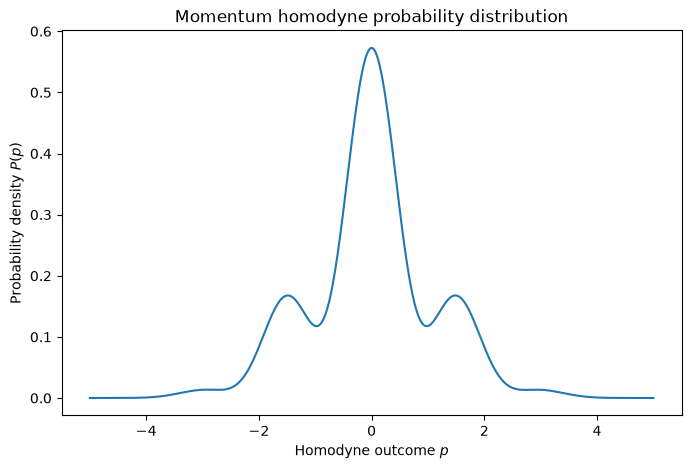

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    p_test,
    pdf_test
)

plt.xlabel("Homodyne outcome $p$")
plt.ylabel("Probability density $P(p)$")
plt.title("Momentum homodyne probability distribution")

plt.show()

In [10]:
from src.homodyne import sample_homodyne

rng = np.random.default_rng(1234)

p_sample = sample_homodyne(
    p_test,
    pdf_test,
    rng=rng
)

print("Sampled homodyne outcome:", p_sample)

Sampled homodyne outcome: 2.173482683683903


In [11]:
from src.homodyne import conditional_state_from_outcome

conditional_state, p_used = (
    conditional_state_from_outcome(
        conditional_unnorm,
        p_test,
        p_sample
    )
)
print("Measurement outcome:", p_sample)
print("Grid value used:", p_used)
print("Norm:", conditional_state.norm())

Measurement outcome: 2.173482683683903
Grid value used: 2.1771771771771773
Norm: 0.9999999999999999


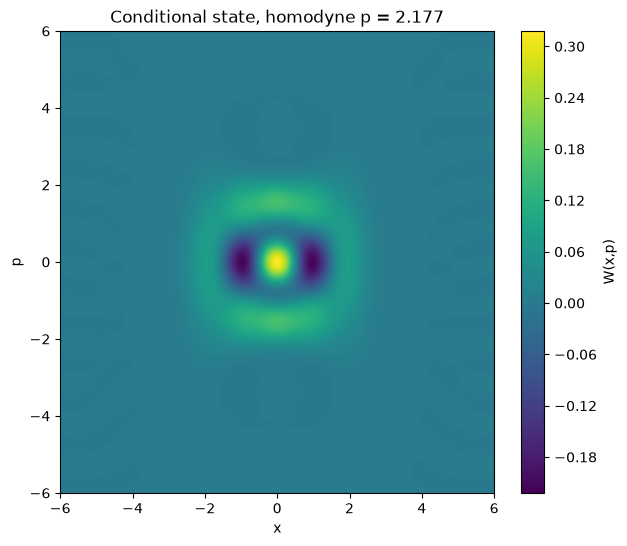

In [12]:
from src.visualisation import plot_wigner

x_wigner = np.linspace(-6, 6, 300)
p_wigner = np.linspace(-6, 6, 300)

plot_wigner(
    conditional_state,
    x_wigner,
    p_wigner,
    title=f"Conditional state, homodyne p = {p_used:.3f}"
)